In [31]:
#names: Trevor Henderson, Valerie Jimenez (Monday and Wednesday)
#dataset: https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset


# Import tools for data handling, visualization, and timing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Import SVM, the two multiclass strategies, and evaluation/preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [32]:
# Load the dry bean dataset from a CSV file
df = pd.read_csv('Dry_Bean_Dataset.csv')

# Print basic dataset info so we know what we are working with
print(f"Number of samples: {len(df)}")
print(f"Number of features: {df.shape[1] - 1}")
print(f"Number of classes: {df['Class'].nunique()}")
print(f"Classes: {df['Class'].unique()}")

Number of samples: 13611
Number of features: 16
Number of classes: 7
Classes: ['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


In [33]:
# SVM only works with numbers, so we convert the bean type names to numeric labels
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
class_names = le.classes_  # save the original names for use in reports and charts later

# Separate features (X) from the target label (y)
X = df.drop(columns=['Class'])
y = df['Class']

# Scale the features so large values like Area don't overpower small ones like ShapeFactor1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# Split the data — 70% for training the model, 30% for testing it
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 9527
Testing samples:  4084


In [35]:
# Track training time so we can compare speed across all three strategies
start_time = time.time()
model_standard = SVC(kernel='rbf', gamma='scale', C=1.0)
model_standard.fit(X_train, y_train)
train_time_standard = time.time() - start_time

# Make predictions and measure accuracy
y_pred_standard = model_standard.predict(X_test)
accuracy_standard = accuracy_score(y_test, y_pred_standard)

print(f"Training time: {train_time_standard:.4f} seconds")
print(f"Accuracy: {accuracy_standard * 100:.2f}%")

Training time: 1.0177 seconds
Accuracy: 93.34%


In [36]:
# Wrap the SVC in OneVsRestClassifier to apply the OvA strategy
start_time = time.time()
model_ovr = OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
model_ovr.fit(X_train, y_train)
train_time_ovr = time.time() - start_time

y_pred_ovr = model_ovr.predict(X_test)
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)

# Print how many individual classifiers were trained under this strategy
print(f"Training time: {train_time_ovr:.4f} seconds")
print(f"Accuracy: {accuracy_ovr * 100:.2f}%")
print(f"Number of classifiers trained: {len(model_ovr.estimators_)}")

Training time: 3.0435 seconds
Accuracy: 93.14%
Number of classifiers trained: 7


In [37]:
# Wrap the SVC in OneVsOneClassifier to apply the OvO strategy
start_time = time.time()
model_ovo = OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
model_ovo.fit(X_train, y_train)
train_time_ovo = time.time() - start_time

y_pred_ovo = model_ovo.predict(X_test)
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)

# Print how many individual classifiers were trained under this strategy
print(f"Training time: {train_time_ovo:.4f} seconds")
print(f"Accuracy: {accuracy_ovo * 100:.2f}%")
print(f"Number of classifiers trained: {len(model_ovo.estimators_)}")

Training time: 0.5938 seconds
Accuracy: 93.27%
Number of classifiers trained: 21


In [38]:
# Print a side-by-side table comparing accuracy, speed, and classifier count
print(f"\n{'Strategy':<20} {'Accuracy':<12} {'Training Time':<15} {'# Classifiers'}")
print("-" * 70)
print(f"{'Standard SVM':<20} {accuracy_standard*100:>6.2f}%     {train_time_standard:>8.4f}s      N/A (built-in)")
print(f"{'One-vs-Rest (OvA)':<20} {accuracy_ovr*100:>6.2f}%     {train_time_ovr:>8.4f}s      {len(model_ovr.estimators_)}")
print(f"{'One-vs-One (OvO)':<20} {accuracy_ovo*100:>6.2f}%     {train_time_ovo:>8.4f}s      {len(model_ovo.estimators_)}")

# Automatically find and print whichever strategy had the highest accuracy
accuracies = {
    'Standard SVM': accuracy_standard,
    'One-vs-Rest (OvA)': accuracy_ovr,
    'One-vs-One (OvO)': accuracy_ovo
}
best_strategy = max(accuracies, key=accuracies.get)
print(f"Best accuracy: {best_strategy}")


Strategy             Accuracy     Training Time   # Classifiers
----------------------------------------------------------------------
Standard SVM          93.34%       1.0177s      N/A (built-in)
One-vs-Rest (OvA)     93.14%       3.0435s      7
One-vs-One (OvO)      93.27%       0.5938s      21
Best accuracy: Standard SVM


In [39]:
# Full breakdown of precision, recall, and F1 for each bean type using OvO
print(classification_report(y_test, y_pred_ovo, target_names=class_names))

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.92      0.93       395
      BOMBAY       1.00      1.00      1.00       161
        CALI       0.94      0.95      0.94       479
    DERMASON       0.92      0.93      0.92      1043
       HOROZ       0.97      0.96      0.96       588
       SEKER       0.96      0.95      0.95       619
        SIRA       0.88      0.89      0.89       799

    accuracy                           0.93      4084
   macro avg       0.94      0.94      0.94      4084
weighted avg       0.93      0.93      0.93      4084



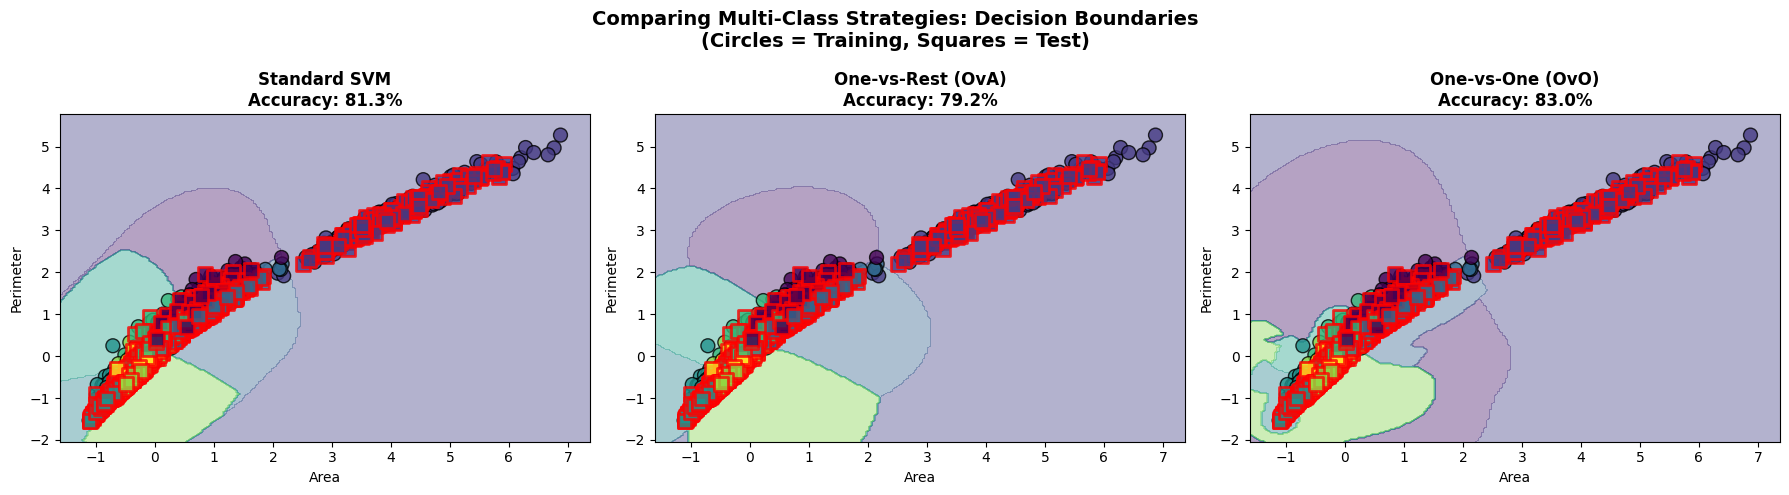

In [40]:
# Use the first 2 features for visualization
X_2d = X_scaled[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)
# Define all three models in a dictionary so we can loop through them
models_2d = {
    'Standard SVM': SVC(kernel='rbf', gamma='scale', C=1.0),
    'One-vs-Rest (OvA)': OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0)),
    'One-vs-One (OvO)': OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Create a mesh grid to fill in the decision regions across the plot area
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
# Train each model and plot its decision boundary side by side
for idx, (name, model) in enumerate(models_2d.items()):
    model.fit(X_train_2d, y_train_2d)
    y_pred_2d = model.predict(X_test_2d)
    acc_2d = accuracy_score(y_test_2d, y_pred_2d)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    axes[idx].scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                      c=y_train_2d, edgecolors='k', cmap='viridis', s=100, alpha=0.8)
    axes[idx].scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                      c=y_test_2d, edgecolors='red', linewidths=2,
                      cmap='viridis', s=100, alpha=0.8, marker='s')
    axes[idx].set_xlabel('Area')
    axes[idx].set_ylabel('Perimeter')
    axes[idx].set_title(f'{name}\nAccuracy: {acc_2d*100:.1f}%',
                        fontsize=12, fontweight='bold')

plt.suptitle('Comparing Multi-Class Strategies: Decision Boundaries\n(Circles = Training, Squares = Test)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# Show how the number of classifiers grows as class count increases
# This highlights the key trade-off between OvA and OvO
print(f"\n{'# Classes':<12} {'One-vs-Rest (OvA)':<20} {'One-vs-One (OvO)'}")
print("-" * 70)

for n_classes in [3, 5, 7, 10, 20, 50, 100]:
    n_ovr = n_classes
    n_ovo = n_classes * (n_classes - 1) // 2
    print(f"{n_classes:<12} {n_ovr:<20} {n_ovo}")

print("\nNotice: OvO grows much faster than OvA as classes increase")


# Classes    One-vs-Rest (OvA)    One-vs-One (OvO)
----------------------------------------------------------------------
3            3                    3
5            5                    10
7            7                    21
10           10                   45
20           20                   190
50           50                   1225
100          100                  4950

Notice: OvO grows much faster than OvA as classes increase


In [43]:
# Show predictions for 10 samples from the test set using all three models
print(f"{'Actual':<20} {'Standard SVM':<20} {'OvA':<20} {'OvO':<20} {'Correct?'}")
print("-" * 95)
for i in range(min(10, len(y_test))):
    actual = str(class_names[y_test.iloc[i]])
    pred_standard = str(class_names[model_standard.predict(X_test[i].reshape(1, -1))[0]])
    pred_ovr = str(class_names[model_ovr.predict(X_test[i].reshape(1, -1))[0]])
    pred_ovo = str(class_names[model_ovo.predict(X_test[i].reshape(1, -1))[0]])
    correct = "✓" if pred_ovo == actual else "✗ (Error)"
    print(f"{actual:<20} {pred_standard:<20} {pred_ovr:<20} {pred_ovo:<20} {correct}")

Actual               Standard SVM         OvA                  OvO                  Correct?
-----------------------------------------------------------------------------------------------
SEKER                SEKER                SEKER                SEKER                ✓
BARBUNYA             BARBUNYA             BARBUNYA             BARBUNYA             ✓
SEKER                SEKER                SEKER                SEKER                ✓
SEKER                SEKER                SEKER                SEKER                ✓
DERMASON             DERMASON             DERMASON             DERMASON             ✓
SEKER                SEKER                SEKER                SEKER                ✓
CALI                 CALI                 CALI                 CALI                 ✓
SEKER                SEKER                SEKER                SEKER                ✓
BOMBAY               BOMBAY               BOMBAY               BOMBAY               ✓
DERMASON             DERMASON        

This program looks at physical measurements of dry beans like size and shape to identify which of seven bean types they belong to. Instead of just one model, we tested three strategies and compared their accuracy and speed. One-vs-Rest asks whether each bean belongs to a specific type or not, while One-vs-One compares every possible pair of bean types against each other and picks the winner by vote. The results show which strategy works best for this type of problem. In the real world, this type of model can be applied to any situation where items need to be sorted into multiple categories automatically, such as classifying products, diagnosing medical conditions, or identifying species in scientific research.